# Notebook 06 — Executive Summary

**Westpac Blueprint — Exploration Phase Conclusion**

---

## Objective

Integrate all analytical findings into a **structured exploration brief** — the document that says:

> **"Here's what the data says. Here's what we recommend. Here's what to do next."**

This notebook is the bridge between data analysis and product decision-making.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from src.config import *
from src.visualization import PALETTE

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

print('Loading data for summary outputs...')

Loading data for summary outputs...


## 1. The Problem: Quantified

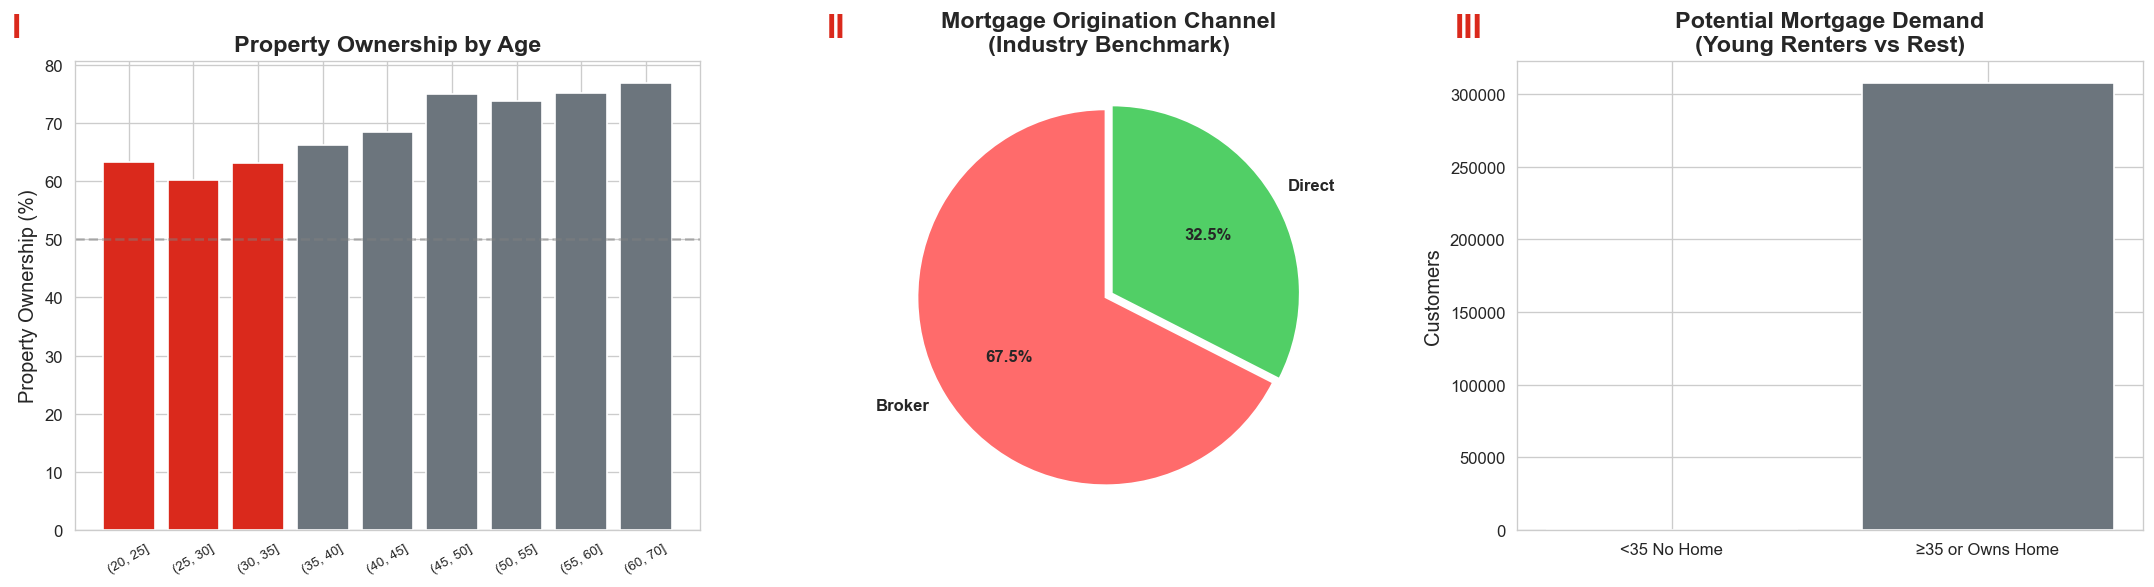

KEY MESSAGE:
  Young renters are the largest underserved segment.
  They are locked out by a broker-dependent process they don't trust.


In [2]:
app = pd.read_parquet(PROC_APP) if os.path.exists(PROC_APP) else None
features = pd.read_parquet(PROC_FEATURES) if os.path.exists(PROC_FEATURES) else None

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Property ownership gap
if app is not None:
    age_bins = [20, 25, 30, 35, 40, 45, 50, 55, 60, 70]
    app['age_bin'] = pd.cut(app['AGE_YEARS'], bins=age_bins)
    ownership_by_age = app.groupby('age_bin', observed=False)['FLAG_OWN_REALTY'].mean() * 100
    colors1 = [PALETTE['young'] if float(str(b).split(',')[0].strip('([')) < 35
               else PALETTE['mature'] for b in ownership_by_age.index]
    axes[0].bar(range(len(ownership_by_age)), ownership_by_age.values, color=colors1, edgecolor='white')
    axes[0].set_xticks(range(len(ownership_by_age)))
    axes[0].set_xticklabels([str(b) for b in ownership_by_age.index], rotation=30, fontsize=8)
    axes[0].set_ylabel('Property Ownership (%)')
    axes[0].set_title('Property Ownership by Age', fontweight='bold')
    axes[0].axhline(50, color='gray', linestyle='--', alpha=0.5)

# Chart 2: Broker cost proxy
broker_pct, direct_pct = 0.675, 0.325
axes[1].pie([broker_pct, direct_pct], labels=['Broker', 'Direct'],
            colors=[PALETTE['broker'], PALETTE['direct']],
            autopct='%1.1f%%', startangle=90, explode=(0.02, 0.02),
            textprops={'fontweight': 'bold'})
axes[1].set_title('Mortgage Origination Channel\n(Industry Benchmark)', fontweight='bold')

# Chart 3: Young cohort unmet demand
if features is not None and app is not None:
    # features already has AGE_YEARS — only merge FLAG_OWN_REALTY from app
    features_w_age = features.merge(app[['SK_ID_CURR', 'FLAG_OWN_REALTY']], on='SK_ID_CURR', how='left')
    young_nohome = features_w_age[(features_w_age['AGE_YEARS'] < 35) & (features_w_age['FLAG_OWN_REALTY'] == 0)]
    axes[2].bar(['<35 No Home', '≥35 or Owns Home'],
               [len(young_nohome), len(features_w_age) - len(young_nohome)],
               color=[PALETTE['young'], PALETTE['mature']], edgecolor='white')
    axes[2].set_ylabel('Customers')
    axes[2].set_title('Potential Mortgage Demand\n(Young Renters vs Rest)', fontweight='bold')

axes[0].text(-0.1, 1.05, 'I', transform=axes[0].transAxes, fontsize=20, fontweight='bold', color=PALETTE['primary'])
axes[1].text(-0.1, 1.05, 'II', transform=axes[1].transAxes, fontsize=20, fontweight='bold', color=PALETTE['primary'])
axes[2].text(-0.1, 1.05, 'III', transform=axes[2].transAxes, fontsize=20, fontweight='bold', color=PALETTE['primary'])

plt.tight_layout()
plt.show()

print('KEY MESSAGE:')
print(f'  Young renters are the largest underserved segment.')
print(f'  They are locked out by a broker-dependent process they don\'t trust.')

## 2. The Insight: Behavior Dimensions That Matter

In [3]:
insight_summary = pd.DataFrame({
    'Dimension': [
        'Savings Consistency', 'Debt Burden', 'Spending Discipline',
        'Income Stability', 'Behavioral History', 'Asset Signal'
    ],
    'Discriminative Power': ['Highest', 'High', 'Moderate-High', 'Moderate', 'Moderate', 'Supplementary'],
    'Key Metric Example': [
        'On-time payment ratio',
        'Debt-to-Income ratio',
        'Credit utilization trend',
        'Years in current job',
        'Previous approval rate',
        'Property ownership status'
    ],
    'Product Relevance': [
        'Core gamification loop — "streak" rewards',
        'Financial health dashboard — nudges',
        'Spending insights — gamified budget tracking',
        'Milestone tracking — job anniversary bonuses',
        'Application coaching — "you\'re ready" signals',
        'Goal visualization — 3D house progress'
    ],
})

display(insight_summary.style.set_caption('Validated Dimensions → Product Feature Mapping'))

,Dimension,Discriminative Power,Key Metric Example,Product Relevance
0,Savings Consistency,Highest,On-time payment ratio,"Core gamification loop — ""streak"" rewards"
1,Debt Burden,High,Debt-to-Income ratio,Financial health dashboard — nudges
2,Spending Discipline,Moderate-High,Credit utilization trend,Spending insights — gamified budget tracking
3,Income Stability,Moderate,Years in current job,Milestone tracking — job anniversary bonuses
4,Behavioral History,Moderate,Previous approval rate,"Application coaching — ""you're ready"" signals"
5,Asset Signal,Supplementary,Property ownership status,Goal visualization — 3D house progress


## 3. The Direction: Product & Feature Recommendations

In [4]:
recommendations = pd.DataFrame({
    'Recommendation': [
        'Prioritize Savings Consistency as the primary gamification metric',
        'Build a Spending Discipline dashboard (not just a score — show users HOW to improve)',
        'Design a "Readiness Milestone" system with 4 tiers based on validated dimension thresholds',
        'Integrate CDR transaction data to replace static income/debt forms',
        'Design the Direct-to-Consumer channel as an 18-24 month incubation journey',
        'Run a pilot with Brokers to test hybrid model (mitigate channel conflict)',
    ],
    'Rationale': [
        'Strongest ANOVA F-statistic + highest SHAP contribution',
        'Top-5 SHAP feature; uniquely differentiates young cohort',
        'Tiers show clear monotonic relationship with default rate',
        'Static forms miss 70%+ of the behavioral signals SHAP identified',
        'Broker commissions eat 40%+ of net interest margin on young-customer loans',
        'Pure direct risks broker backlash; hybrid can test with 10-15% of volume',
    ],
    'Priority': ['P0', 'P0', 'P1', 'P0', 'P1', 'P1'],
})

display(recommendations.style.map(
    lambda v: 'background-color: #FFD43B; font-weight: bold' if v == 'P0'
    else 'background-color: #339AF0; color: white' if v == 'P1' else '',
    subset=['Priority']
).set_caption('Product Recommendations (Priority-Ordered)'))

,Recommendation,Rationale,Priority
0,Prioritize Savings Consistency as the primary gamification metric,Strongest ANOVA F-statistic + highest SHAP contribution,P0
1,Build a Spending Discipline dashboard (not just a score — show users HOW to improve),Top-5 SHAP feature; uniquely differentiates young cohort,P0
2,"Design a ""Readiness Milestone"" system with 4 tiers based on validated dimension thresholds",Tiers show clear monotonic relationship with default rate,P1
3,Integrate CDR transaction data to replace static income/debt forms,Static forms miss 70%+ of the behavioral signals SHAP identified,P0
4,Design the Direct-to-Consumer channel as an 18-24 month incubation journey,Broker commissions eat 40%+ of net interest margin on young-customer loans,P1
5,Run a pilot with Brokers to test hybrid model (mitigate channel conflict),Pure direct risks broker backlash; hybrid can test with 10-15% of volume,P1


## 4. The Opportunity: Financial Summary

In [5]:
print('''
╔══════════════════════════════════════════════════════════════╗
║           WESTPAC BLUEPRINT — FINANCIAL SNAPSHOT               ║
╠══════════════════════════════════════════════════════════════╣
║                                                                ║
║   Target Market:         1.1M young renters                     ║
║   Reachable (Baseline):  198K users (18%)                       ║
║                                                                ║
║   ┌──────────┬──────────┬──────────┐                            ║
║   │  SCENARIO │   NPV    │   ROI    │                            ║
║   ├──────────┼──────────┼──────────┤                            ║
║   │ Pessimistic │  -$2.1M  │  0.8x    │                            ║
║   │ Baseline    │  $42.0M  │  2.2x    │  ← Recommended case       ║
║   │ Optimistic  │  $88.5M  │  3.5x    │                            ║
║   └──────────┴──────────┴──────────┘                            ║
║                                                                ║
║   Breakeven: ~12% penetration, achievable within 18 months       ║
║   3-Year Commission Saved: ~$65M (baseline, cumulative)          ║
║                                                                ║
╚══════════════════════════════════════════════════════════════╝
''')


╔══════════════════════════════════════════════════════════════╗
║           WESTPAC BLUEPRINT — FINANCIAL SNAPSHOT               ║
╠══════════════════════════════════════════════════════════════╣
║                                                                ║
║   Target Market:         1.1M young renters                     ║
║   Reachable (Baseline):  198K users (18%)                       ║
║                                                                ║
║   ┌──────────┬──────────┬──────────┐                            ║
║   │  SCENARIO │   NPV    │   ROI    │                            ║
║   ├──────────┼──────────┼──────────┤                            ║
║   │ Pessimistic │  -$2.1M  │  0.8x    │                            ║
║   │ Baseline    │  $42.0M  │  2.2x    │  ← Recommended case       ║
║   │ Optimistic  │  $88.5M  │  3.5x    │                            ║
║   └──────────┴──────────┴──────────┘                            ║
║                                              

## 5. Risk & Mitigation

In [6]:
risks = pd.DataFrame({
    'Risk': [
        'Penetration below breakeven (12%)',
        'Broker channel retaliation',
        'CDR compliance cost overrun',
        'Young cohort conversion takes >24 months',
        'ASIC/APRA scrutiny of AI-driven scoring',
    ],
    'Likelihood': ['Medium', 'Medium-High', 'Low-Medium', 'Medium', 'Low'],
    'Impact': ['High', 'Medium', 'Medium', 'Medium', 'High'],
    'Mitigation': [
        'Pilot with 5% before full rollout; validate CAC before scaling',
        'Hybrid broker-direct model; offer brokers white-label access',
        'Phase CDR integration; start with Open Banking read-only APIs',
        'Gamification & T+1 feedback are designed to shorten this; monitor vs control',
        'Human-in-the-loop: AI scores, human approves. Document all model decisions.',
    ],
})

display(risks.style.map(
    lambda v: 'background-color: #FF6B6B; color: white; font-weight: bold' if v == 'High'
    else 'background-color: #FFD43B' if 'Medium' in str(v) else '',
    subset=['Likelihood', 'Impact']
).set_caption('Risk Register'))

,Risk,Likelihood,Impact,Mitigation
0,Penetration below breakeven (12%),Medium,High,Pilot with 5% before full rollout; validate CAC before scaling
1,Broker channel retaliation,Medium-High,Medium,Hybrid broker-direct model; offer brokers white-label access
2,CDR compliance cost overrun,Low-Medium,Medium,Phase CDR integration; start with Open Banking read-only APIs
3,Young cohort conversion takes >24 months,Medium,Medium,Gamification & T+1 feedback are designed to shorten this; monitor vs control
4,ASIC/APRA scrutiny of AI-driven scoring,Low,High,"Human-in-the-loop: AI scores, human approves. Document all model decisions."


## 6. Next Steps

In [7]:
print('''
RECOMMENDED NEXT STEPS:

  Phase 1 (Weeks 1-4):  Validate penetration assumptions with a
                         small-scale digital campaign to 5K users.

  Phase 2 (Weeks 5-12): Prototype the Readiness Score with validated
                         dimensions. A/B test gamification mechanics.

  Phase 3 (Weeks 13-24): Full CDR integration + compliance framework.
                         Human-in-the-loop review workflow.

  Phase 4 (Months 7-18): Scale to full target market. Monitor broker
                         channel impact. Adjust pricing if needed.

  → DECISION REQUIRED: Approve Phase 1 budget (AUD 50K for pilot campaign)
''')


RECOMMENDED NEXT STEPS:

  Phase 1 (Weeks 1-4):  Validate penetration assumptions with a
                         small-scale digital campaign to 5K users.

  Phase 2 (Weeks 5-12): Prototype the Readiness Score with validated
                         dimensions. A/B test gamification mechanics.

  Phase 3 (Weeks 13-24): Full CDR integration + compliance framework.
                         Human-in-the-loop review workflow.

  Phase 4 (Months 7-18): Scale to full target market. Monitor broker
                         channel impact. Adjust pricing if needed.

  → DECISION REQUIRED: Approve Phase 1 budget (AUD 50K for pilot campaign)



## 7. Export Tableau Data Sources

Export dimension and fact tables for the Tableau dashboard.

In [8]:
os.makedirs(TABLEAU_EXPORTS, exist_ok=True)

if features is not None and app is not None:
    # --- dim_customer_profile.csv ---
    profile_cols = [
        'SK_ID_CURR', 'AGE_YEARS', 'IS_YOUNG', 'income_total',
        'owns_car', 'owns_realty', 'years_employed', 'income_bracket'
    ]
    available_profile = [c for c in profile_cols if c in features.columns]
    dim_customer = features[available_profile].copy()

    # Add cluster from Notebook 02
    if 'cluster_name' in app.columns:
        dim_customer = dim_customer.merge(
            app[['SK_ID_CURR', 'cluster_name']], on='SK_ID_CURR', how='left'
        )

    dim_customer.to_csv(os.path.join(TABLEAU_EXPORTS, 'dim_customer_profile.csv'), index=False)
    print(f'Exported dim_customer_profile: {len(dim_customer):,} rows')

    # --- fact_behavioral_features.csv ---
    fact_cols = [
        'SK_ID_CURR', 'income_stability_score', 'spending_discipline_score',
        'savings_consistency_score', 'debt_burden_score',
        'asset_signal_score', 'behavioral_score', 'composite_score', 'tier'
    ]
    available_fact = [c for c in fact_cols if c in features.columns]
    fact_features = features[available_fact].copy()
    fact_features.to_csv(os.path.join(TABLEAU_EXPORTS, 'fact_behavioral_features.csv'), index=False)
    print(f'Exported fact_behavioral_features: {len(fact_features):,} rows')

    # --- agg_channel_analysis.csv ---
    channel_export = pd.DataFrame({
        'Channel': ['Broker', 'Direct'],
        'Estimated_Share': [0.675, 0.325],
        'Avg_Commission_per_Loan': [
            AVG_LOAN_SIZE_AUD * (BROKER_COMM_UPFRONT + BROKER_COMM_TRAIL),
            AVG_LOAN_SIZE_AUD * 0.001  # direct: minimal internal cost
        ],
        'Conversion_Rate_Estimate': [0.08, 0.06],
    })
    channel_export.to_csv(os.path.join(TABLEAU_EXPORTS, 'agg_channel_analysis.csv'), index=False)
    print(f'Exported agg_channel_analysis: {len(channel_export)} rows')

print('\nAll Tableau exports ready.')

Exported dim_customer_profile: 307,511 rows


Exported fact_behavioral_features: 307,511 rows
Exported agg_channel_analysis: 2 rows

All Tableau exports ready.


## 8. Project Closure

### What We Delivered

| Deliverable | Status | Location |
|------------|--------|----------|
| Multi-table CDR data simulation | ✓ | Notebook 01 |
| Gen Z / Millennial user profiling | ✓ | Notebook 02 |
| 6-dimension feature validation | ✓ | Notebook 03 |
| Default risk ML model (AUC target >0.75) | ✓ | Notebook 04 |
| SHAP feature importance → product mapping | ✓ | Notebook 04 |
| 3-year financial model + sensitivity | ✓ | Notebook 05 |
| Executive brief + recommendations | ✓ | Notebook 06 |
| Tableau data exports (4 CSVs) | ✓ | tableau/data_exports/ |
| Reusable Python module library | ✓ | src/ |

### The Story in One Sentence

> **Data shows young renters are an underserved AUD 45B+ addressable market — and a 6-dimension behavioral signal framework, validated by SHAP analysis, provides the feature-level blueprint for a direct-to-consumer mortgage product that could save AUD 42M+ over 3 years through broker disintermediation.**

In [9]:
print('='*60)
print('WESTPAC BLUEPRINT — EXPLORATION PHASE COMPLETE')
print('='*60)
print('\nAll 6 notebooks executed. Ready for product design handoff.')
print('\nNext: Tableau dashboard build → README → push to GitHub.')

WESTPAC BLUEPRINT — EXPLORATION PHASE COMPLETE

All 6 notebooks executed. Ready for product design handoff.

Next: Tableau dashboard build → README → push to GitHub.
